# Dirty vs Clean Classification Ablations

**Task:** Classify CCTV crops of restaurant tables as `clean` or `dirty`.

**Data:** Dirty samples keep the existing 3-frame method (`frame_0`, `frame_1`, `frame_2`); clean samples use `frame_2` only.

**Key Features:**
- Binary labels only: `clean`, `dirty`
- Group-based train/val/test split by video/table stem
- Train-only clean undersampling at 3:1 clean:dirty
- DINOv3, ResNet18, and ResNet50 ablations
- 3-fold grouped cross-validation
- Loss/F1/dirty precision/dirty recall plots over time


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os

base_dir = "/content/drive/Shared drives/shire drive"

print(f"Checking path: {base_dir}")
if os.path.exists(base_dir):
    print("\n✅ Success! 'shire drive' found. Here is what is inside:")
    items = os.listdir(base_dir)
    for item in items:
        print(f" - {item}")
else:
    print(f"\n❌ Could not find {base_dir}")


Checking path: /content/drive/Shared drives/shire drive

✅ Success! 'shire drive' found. Here is what is inside:
 - SHIRELABELING


In [13]:
!pip install -q huggingface_hub
from huggingface_hub import notebook_login

notebook_login()

In [14]:
import os
import re
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from PIL import Image
from collections import Counter, defaultdict
from torchvision import transforms
import torchvision.models as tv_models
from torch.utils.data import DataLoader
from transformers import AutoModel

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import sys
print(f"Python version: {sys.version}")


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [15]:
# =============================================================================
# CONFIGURATION
# =============================================================================

DATA_DIR = "/content/drive/Shared drives/shire drive/SHIRELABELING"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

EMBED_DIMS = {"small": 384, "base": 768, "large": 1024, "huge": 1280}
BACKBONE_SIZE = "large"

BATCH_SIZE = 16
NUM_WORKERS = 0  # Set to 0 to avoid DataLoader worker crashes in Colab
NUM_EPOCHS = 50
CV_EPOCHS = 15  # Cross-validation is for comparison signal; final runs use NUM_EPOCHS.
LEARNING_RATE = 3e-4
RESNET_LR = 1e-4
BACKBONE_LR = 1e-06
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
EARLY_STOPPING_PATIENCE = 10
DROPOUT = 0.3
UNFREEZE_LAST_N = 2

FOCAL_LOSS_GAMMA = 2.0
USE_CLASS_WEIGHTS = False  # Keep this off while using explicit train-only undersampling.

CLASSES = ['clean', 'dirty']
DIRTY_FRAME_NUMS = [0, 1, 2]
CLEAN_FRAME_NUMS = [2]
UNDERSAMPLE_CLEAN_TRAIN = True
CLEAN_TO_DIRTY_TRAIN_RATIO = 3

ABLATION_MODELS = ["dinov3", "resnet18", "resnet50"]
FINAL_MODEL_NAME = "dinov3"
RUN_CV = True
CV_FOLDS = 3

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# DINOv3 backbone registry. ResNet backbones are loaded in build_model().
HF_MODELS = {
    "small": "facebook/dinov3-vits16-pretrain-lvd1689m",
    "base": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "large": "facebook/dinov3-vitl16-pretrain-lvd1689m",
}

embed_dim = EMBED_DIMS[BACKBONE_SIZE]

def load_dinov3_backbone():
    print(f"Loading DINOv3 {BACKBONE_SIZE} from HuggingFace...")
    loaded_backbone = AutoModel.from_pretrained(HF_MODELS[BACKBONE_SIZE], trust_remote_code=True)
    print(f"Embed dim: {embed_dim}")
    print(f"Backbone params: {sum(p.numel() for p in loaded_backbone.parameters()):,}")
    return loaded_backbone

backbone = None  # Loaded fresh inside build_model() so each ablation/fold starts from pretrained weights.
print(f"Configured DINOv3 {BACKBONE_SIZE} with embed dim {embed_dim}")


Configured DINOv3 large with embed dim 1024


In [18]:
# Discover samples. Dirty keeps the requested 3-frame method; clean uses frame_2 only.
num_classes = len(CLASSES)
id2label = {i: c for i, c in enumerate(CLASSES)}
label2id = {c: i for i, c in id2label.items()}
assert CLASSES == ['clean', 'dirty'], f"Expected binary clean/dirty classes, got: {CLASSES}"
assert num_classes == 2, f"Expected exactly 2 classes, got {num_classes}"

frame_nums_by_class = {
    'clean': CLEAN_FRAME_NUMS,
    'dirty': DIRTY_FRAME_NUMS,
}

samples = []  # list of (frame_path, label_idx, folder_name, frame_num)
folder_counts = Counter()
missing_frames = defaultdict(int)

for label_name in CLASSES:
    label_dir = os.path.join(DATA_DIR, label_name)
    if not os.path.isdir(label_dir):
        print(f"WARNING: {label_dir} not found, skipping")
        continue

    for folder_name in sorted(os.listdir(label_dir)):
        folder_path = os.path.join(label_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue

        folder_counts[label_name] += 1
        for frame_num in frame_nums_by_class[label_name]:
            frame_path = os.path.join(folder_path, f"frame_{frame_num}.jpg")
            if os.path.exists(frame_path):
                samples.append((frame_path, label2id[label_name], folder_name, frame_num))
            else:
                missing_frames[(label_name, frame_num)] += 1

labels = [s[1] for s in samples]
folder_names = [s[2] for s in samples]
frame_nums = [s[3] for s in samples]

print(f"Classes: {CLASSES}")
print(f"Total frame samples: {len(samples)}")
print("\nRaw folder counts:")
for label_name in CLASSES:
    print(f"  {label_name}: {folder_counts[label_name]}")

class_counts = Counter(labels)
print("\nFrame-sample class distribution:")
for idx, count in sorted(class_counts.items()):
    print(f"  {id2label[idx]}: {count} ({100*count/len(samples):.1f}%)")

print("\nFrames used per class:")
for label_name in CLASSES:
    print(f"  {label_name}: {frame_nums_by_class[label_name]}")

if missing_frames:
    print("\nMissing frame counts:")
    for (label_name, frame_num), count in sorted(missing_frames.items()):
        print(f"  {label_name} frame_{frame_num}: {count}")


Classes: ['clean', 'dirty']
Total frame samples: 2822

Raw folder counts:
  clean: 2463
  dirty: 120

Frame-sample class distribution:
  clean: 2462 (87.2%)
  dirty: 360 (12.8%)

Frames used per class:
  clean: [2]
  dirty: [0, 1, 2]

Missing frame counts:
  clean frame_2: 1


### Data Distribution Summary
To answer your question directly:
- **Total Frames:** 2,822
- **Clean Frames:** 2,462
- **Dirty Frames:** 360

**The Problem:** Since you use 3 frames per dirty folder and only 1 for clean, you actually only have **120 unique 'dirty' situations** in total. In your current training split, you are trying to learn the concept of 'dirty' from only **48 unique videos/folders** (144 frames / 3). This is why the model is memorizing; it's practically looking at a few dozen photos and memorizing their names.

In [19]:
from sklearn.model_selection import GroupShuffleSplit


def get_group_id(folder_name):
    # Group by video_stem + table_id, stripping the triplet index suffix.
    # Example: IPC11_2024-01-15_table_top_5_t0003 -> IPC11_2024-01-15_table_top_5
    return re.sub(r"_t\d{4}$", "", folder_name)


def label_counts(indices):
    counts = Counter(labels[i] for i in indices)
    return {id2label[i]: counts.get(i, 0) for i in range(num_classes)}


def print_split_counts(name, indices):
    counts = label_counts(indices)
    total = len(indices)
    clean_count = counts.get('clean', 0)
    dirty_count = counts.get('dirty', 0)
    dirty_pct = 100 * dirty_count / total if total else 0
    print(f"{name}: {total} samples | clean={clean_count} | dirty={dirty_count} ({dirty_pct:.1f}% dirty)")

indices = list(range(len(samples)))
groups = [get_group_id(folder_names[i]) for i in indices]
unique_groups = set(groups)
print(f"Found {len(unique_groups)} unique video+table groups across {len(indices)} samples")

# Group-based split: all triplets from same video+table go to same split.
gss_train = GroupShuffleSplit(n_splits=1, test_size=(VAL_RATIO + TEST_RATIO), random_state=SEED)
train_idx, temp_idx = next(gss_train.split(indices, labels, groups))
train_idx, temp_idx = list(train_idx), list(temp_idx)

temp_groups = [groups[i] for i in temp_idx]
temp_labels = [labels[i] for i in temp_idx]
gss_valtest = GroupShuffleSplit(n_splits=1, test_size=TEST_RATIO/(VAL_RATIO+TEST_RATIO), random_state=SEED)
val_idx_rel, test_idx_rel = next(gss_valtest.split(range(len(temp_idx)), temp_labels, temp_groups))
val_idx = [temp_idx[i] for i in val_idx_rel]
test_idx = [temp_idx[i] for i in test_idx_rel]

print("\nNatural split distributions before train-only undersampling:")
print_split_counts("Train", train_idx)
print_split_counts("Val", val_idx)
print_split_counts("Test", test_idx)

# Verify no group leakage.
train_groups = set(groups[i] for i in train_idx)
val_groups = set(groups[i] for i in val_idx)
test_groups = set(groups[i] for i in test_idx)
assert len(train_groups & val_groups) == 0, "Leakage between train and val!"
assert len(train_groups & test_groups) == 0, "Leakage between train and test!"
assert len(val_groups & test_groups) == 0, "Leakage between val and test!"
print("No group leakage detected")


Found 203 unique video+table groups across 2822 samples

Natural split distributions before train-only undersampling:
Train: 1944 samples | clean=1800 | dirty=144 (7.4% dirty)
Val: 508 samples | clean=391 | dirty=117 (23.0% dirty)
Test: 370 samples | clean=271 | dirty=99 (26.8% dirty)
No group leakage detected


In [20]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Refined augmentation: protects small dirty features while preventing memorization.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.05)),
])

class DINOv3Dataset(torch.utils.data.Dataset):
    def __init__(self, samples, indices, transform=None):
        self.samples = samples
        self.indices = list(indices)
        self.transform = transform or val_transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        path, label, _, _ = self.samples[self.indices[idx]]
        img = Image.open(path)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return self.transform(img), label


def undersample_clean_train_indices(indices, labels, clean_to_dirty_ratio=CLEAN_TO_DIRTY_TRAIN_RATIO, seed=SEED):
    # Keep all dirty samples and cap clean samples to ratio * dirty for training only.
    dirty_label = label2id['dirty']
    clean_label = label2id['clean']
    dirty_indices = [i for i in indices if labels[i] == dirty_label]
    clean_indices = [i for i in indices if labels[i] == clean_label]

    if not UNDERSAMPLE_CLEAN_TRAIN or not dirty_indices:
        balanced = list(indices)
    else:
        max_clean = min(len(clean_indices), clean_to_dirty_ratio * len(dirty_indices))
        rng = random.Random(seed)
        selected_clean = rng.sample(clean_indices, max_clean) if max_clean < len(clean_indices) else list(clean_indices)
        balanced = selected_clean + dirty_indices
        rng.shuffle(balanced)

    return balanced


def make_loaders(train_indices, val_indices, test_indices=None, seed=SEED, undersample_train=True):
    if undersample_train:
        train_indices_for_loader = undersample_clean_train_indices(train_indices, labels, seed=seed)
    else:
        train_indices_for_loader = list(train_indices)

    print("\nLoader split distributions:")
    print_split_counts("Train loader", train_indices_for_loader)
    print_split_counts("Val loader", val_indices)
    if test_indices is not None:
        print_split_counts("Test loader", test_indices)

    train_ds = DINOv3Dataset(samples, train_indices_for_loader, transform=train_transform)
    val_ds = DINOv3Dataset(samples, val_indices)
    test_ds = DINOv3Dataset(samples, test_indices) if test_indices is not None else None

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
    )
    val_loader = DataLoader(val_ds, BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True) if test_ds is not None else None
    return train_loader, val_loader, test_loader, train_indices_for_loader

train_loader, val_loader, test_loader, balanced_train_idx = make_loaders(train_idx, val_idx, test_idx, seed=SEED)
print(f"Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")



Loader split distributions:
Train loader: 576 samples | clean=432 | dirty=144 (25.0% dirty)
Val loader: 508 samples | clean=391 | dirty=117 (23.0% dirty)
Test loader: 370 samples | clean=271 | dirty=99 (26.8% dirty)
Batches - Train: 36 | Val: 32 | Test: 24


In [21]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha, self.gamma, self.label_smoothing = alpha, gamma, label_smoothing
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        fl = (1-pt)**self.gamma * ce
        return (self.alpha[targets] * fl if self.alpha is not None else fl).mean()

In [22]:
class DINOv3Classifier(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes, dropout=0.15, unfreeze_last_n=0):
        super().__init__()
        self.backbone = backbone
        self.unfreeze_last_n = unfreeze_last_n

        # Freeze entire backbone first.
        for p in backbone.parameters():
            p.requires_grad = False

        # Selectively unfreeze last N encoder blocks.
        if unfreeze_last_n > 0:
            if hasattr(backbone, 'vit'):
                encoder_layers = backbone.vit.encoder.layer
            elif hasattr(backbone, 'encoder'):
                encoder_layers = backbone.encoder.layer
            else:
                encoder_layers = backbone.layers if hasattr(backbone, 'layers') else []

            if encoder_layers:
                for layer in encoder_layers[-unfreeze_last_n:]:
                    for p in layer.parameters():
                        p.requires_grad = True

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
        self.embed_dim = embed_dim

    def get_backbone_params(self):
        return [p for p in self.backbone.parameters() if p.requires_grad]

    def forward(self, x):
        if self.unfreeze_last_n > 0:
            out = self.backbone(x)
        else:
            with torch.no_grad():
                out = self.backbone(x)

        if hasattr(out, 'last_hidden_state'):
            cls_token = out.last_hidden_state[:, 0]
        elif isinstance(out, dict) and 'x_norm_clstoken' in out:
            cls_token = out['x_norm_clstoken']
        else:
            cls_token = out[0][:, 0] if isinstance(out, (list, tuple)) else out[:, 0]

        return self.head(cls_token)

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        if self.unfreeze_last_n > 0:
            if hasattr(self.backbone, 'vit'):
                layers = self.backbone.vit.encoder.layer
            elif hasattr(self.backbone, 'encoder'):
                layers = self.backbone.encoder.layer
            else:
                layers = getattr(self.backbone, 'layers', [])

            for layer in layers[-self.unfreeze_last_n:]:
                layer.train(mode)
        return self


def build_resnet(model_name, num_classes):
    if model_name == 'resnet18':
        weights = tv_models.ResNet18_Weights.DEFAULT
        model = tv_models.resnet18(weights=weights)
    elif model_name == 'resnet50':
        weights = tv_models.ResNet50_Weights.DEFAULT
        model = tv_models.resnet50(weights=weights)
    else:
        raise ValueError(f"Unknown ResNet model: {model_name}")

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(DROPOUT),
        nn.Linear(in_features, num_classes),
    )
    return model


def build_model(model_name):
    if model_name == 'dinov3':
        return DINOv3Classifier(load_dinov3_backbone(), embed_dim, num_classes, dropout=DROPOUT, unfreeze_last_n=UNFREEZE_LAST_N)
    if model_name in {'resnet18', 'resnet50'}:
        return build_resnet(model_name, num_classes)
    raise ValueError(f"Unknown model_name: {model_name}")


def model_config(model_name, epochs):
    if model_name == 'dinov3':
        return {
            'epochs': epochs,
            'lr': LEARNING_RATE,
            'backbone_lr': BACKBONE_LR,
            'weight_decay': WEIGHT_DECAY,
        }
    return {
        'epochs': epochs,
        'lr': RESNET_LR,
        'backbone_lr': None,
        'weight_decay': WEIGHT_DECAY,
    }


In [23]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.best_state = None

    def __call__(self, val_metric, model):
        if self.best_score is None or val_metric > self.best_score + 0.001:
            self.best_score = val_metric
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


def compute_metrics(y_true, y_pred):
    return {
        'acc': accuracy_score(y_true, y_pred),
        'dirty_recall': recall_score(y_true, y_pred, zero_division=0),
        'dirty_precision': precision_score(y_true, y_pred, zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
    }


def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, preds, y_true = 0, [], []

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        if trainable_params:
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        preds.extend(logits.argmax(1).detach().cpu().numpy())
        y_true.extend(y.detach().cpu().numpy())

    metrics = compute_metrics(y_true, preds)
    return total_loss / max(1, len(loader)), metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds, y_true = 0, [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item()
        preds.extend(logits.argmax(1).detach().cpu().numpy())
        y_true.extend(y.detach().cpu().numpy())

    metrics = compute_metrics(y_true, preds)
    return total_loss / max(1, len(loader)), metrics, preds, y_true


In [24]:
def make_optimizer_and_scheduler(model, model_name, config, train_loader):
    if model_name == 'dinov3':
        param_groups = [{'params': list(model.head.parameters()), 'lr': config['lr']}]
        backbone_params = model.get_backbone_params()
        if backbone_params:
            param_groups.append({'params': backbone_params, 'lr': config['backbone_lr']})
    else:
        param_groups = [{'params': [p for p in model.parameters() if p.requires_grad], 'lr': config['lr']}]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=config['weight_decay'])
    total_steps = max(1, len(train_loader) * config['epochs'])
    warmup_steps = max(1, int(WARMUP_RATIO * total_steps))

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler


def train_model(model, model_name, train_loader, val_loader, config, device):
    model = model.to(device)
    criterion = FocalLoss(alpha=None, gamma=FOCAL_LOSS_GAMMA, label_smoothing=LABEL_SMOOTHING)
    optimizer, scheduler = make_optimizer_and_scheduler(model, model_name, config, train_loader)
    early_stopping = EarlyStopping(EARLY_STOPPING_PATIENCE)
    history = []

    for epoch in range(config['epochs']):
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device)

        row = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_macro_f1': train_metrics['macro_f1'],
            'val_macro_f1': val_metrics['macro_f1'],
            'train_dirty_precision': train_metrics['dirty_precision'],
            'val_dirty_precision': val_metrics['dirty_precision'],
            'train_dirty_recall': train_metrics['dirty_recall'],
            'val_dirty_recall': val_metrics['dirty_recall'],
            'train_acc': train_metrics['acc'],
            'val_acc': val_metrics['acc'],
        }
        history.append(row)

        print(f"{model_name} Epoch {epoch+1}:")
        print(f"  Train -> Loss: {train_loss:.4f} | Macro F1: {100*train_metrics['macro_f1']:.1f}% | Acc: {100*train_metrics['acc']:.1f}% | Prec (Dirty): {100*train_metrics['dirty_precision']:.1f}% | Rec (Dirty): {100*train_metrics['dirty_recall']:.1f}%")
        print(f"  Val   -> Loss: {val_loss:.4f} | Macro F1: {100*val_metrics['macro_f1']:.1f}% | Acc: {100*val_metrics['acc']:.1f}% | Prec (Dirty): {100*val_metrics['dirty_precision']:.1f}% | Rec (Dirty): {100*val_metrics['dirty_recall']:.1f}%")

        if early_stopping(val_metrics['macro_f1'], model):
            print(f"Early stopping {model_name} at epoch {epoch+1}")
            break

    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)
    return model.to(device), early_stopping.best_score, pd.DataFrame(history)


In [25]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

@torch.no_grad()
def get_probabilities(model, loader, device):
    model.eval()
    probs, y_true = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, label2id['dirty']]
        probs.extend(prob.cpu().numpy())
        y_true.extend(y.numpy())
    return np.array(probs), np.array(y_true)


def find_best_threshold(y_true, probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = int(np.argmax(f1_scores))
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5


def evaluate_with_threshold(model, val_loader, test_loader, device):
    val_probs, val_labels = get_probabilities(model, val_loader, device)
    best_threshold = find_best_threshold(val_labels, val_probs)

    test_probs, test_labels = get_probabilities(model, test_loader, device)
    test_preds = (test_probs >= best_threshold).astype(int)
    metrics = compute_metrics(test_labels, test_preds)
    return best_threshold, metrics, test_labels, test_preds


def plot_history(history_by_model):
    for metric_group, columns, title in [
        ('loss', ['train_loss', 'val_loss'], 'Loss over epochs'),
        ('macro_f1', ['train_macro_f1', 'val_macro_f1'], 'Macro F1 over epochs'),
        ('dirty_precision_recall', ['val_dirty_precision', 'val_dirty_recall'], 'Validation dirty precision/recall over epochs'),
    ]:
        plt.figure(figsize=(10, 5))
        for model_name, history in history_by_model.items():
            if history.empty:
                continue
            for col in columns:
                plt.plot(history['epoch'], history[col], label=f"{model_name} {col}")
        plt.title(title)
        plt.xlabel('Epoch')
        plt.ylabel(metric_group)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


def plot_model_comparison(results_df, cv_summary_df=None):
    if results_df.empty:
        return
    display_cols = ['model_name', 'test_macro_f1', 'test_dirty_precision', 'test_dirty_recall', 'test_acc', 'best_threshold']
    display(results_df[display_cols].sort_values('test_macro_f1', ascending=False))

    melted = results_df.melt(
        id_vars='model_name',
        value_vars=['test_macro_f1', 'test_dirty_precision', 'test_dirty_recall', 'test_acc'],
        var_name='metric',
        value_name='score',
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melted, x='model_name', y='score', hue='metric')
    plt.ylim(0, 1)
    plt.title('Final test metrics by model')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    if cv_summary_df is not None and not cv_summary_df.empty:
        display(cv_summary_df)


In [26]:
from sklearn.model_selection import GroupKFold


def run_group_cv(model_names):
    if not RUN_CV:
        print("Skipping CV because RUN_CV=False")
        return pd.DataFrame(), pd.DataFrame()

    n_splits = min(CV_FOLDS, len(set(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    rows = []

    for fold, (fold_train_idx, fold_val_idx) in enumerate(gkf.split(indices, labels, groups), start=1):
        fold_train_idx = list(fold_train_idx)
        fold_val_idx = list(fold_val_idx)
        print(f"\n===== CV fold {fold}/{n_splits} =====")
        print_split_counts("Fold train natural", fold_train_idx)
        print_split_counts("Fold val natural", fold_val_idx)

        for model_name in model_names:
            print(f"\n--- CV {model_name} fold {fold} ---")
            set_seed(SEED + fold)
            fold_train_loader, fold_val_loader, _, fold_balanced_idx = make_loaders(
                fold_train_idx,
                fold_val_idx,
                test_indices=None,
                seed=SEED + fold,
                undersample_train=True,
            )

            model_cv = build_model(model_name)
            trained_cv, best_val_f1, history = train_model(
                model_cv,
                model_name,
                fold_train_loader,
                fold_val_loader,
                model_config(model_name, CV_EPOCHS),
                device,
            )

            last_row = history.iloc[-1].to_dict() if not history.empty else {}
            rows.append({
                'model_name': model_name,
                'fold': fold,
                'train_samples_after_undersampling': len(fold_balanced_idx),
                'best_val_macro_f1': best_val_f1,
                'last_val_macro_f1': last_row.get('val_macro_f1', np.nan),
                'last_val_dirty_precision': last_row.get('val_dirty_precision', np.nan),
                'last_val_dirty_recall': last_row.get('val_dirty_recall', np.nan),
                'last_val_loss': last_row.get('val_loss', np.nan),
            })

            del trained_cv, model_cv
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    cv_df = pd.DataFrame(rows)
    if cv_df.empty:
        return cv_df, pd.DataFrame()

    cv_summary = cv_df.groupby('model_name').agg(
        best_val_macro_f1_mean=('best_val_macro_f1', 'mean'),
        best_val_macro_f1_std=('best_val_macro_f1', 'std'),
        dirty_precision_mean=('last_val_dirty_precision', 'mean'),
        dirty_precision_std=('last_val_dirty_precision', 'std'),
        dirty_recall_mean=('last_val_dirty_recall', 'mean'),
        dirty_recall_std=('last_val_dirty_recall', 'std'),
        val_loss_mean=('last_val_loss', 'mean'),
    ).reset_index()
    return cv_df, cv_summary


cv_results_df, cv_summary_df = run_group_cv(ABLATION_MODELS)
if not cv_results_df.empty:
    display(cv_results_df)
    display(cv_summary_df)



===== CV fold 1/3 =====
Fold train natural: 1881 samples | clean=1680 | dirty=201 (10.7% dirty)
Fold val natural: 941 samples | clean=782 | dirty=159 (16.9% dirty)

--- CV dinov3 fold 1 ---

Loader split distributions:
Train loader: 804 samples | clean=603 | dirty=201 (25.0% dirty)
Val loader: 941 samples | clean=782 | dirty=159 (16.9% dirty)
Loading DINOv3 large from HuggingFace...


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Embed dim: 1024
Backbone params: 303,129,600


...

resnet50 Epoch 13:
  Train -> Loss: 0.0077 | Macro F1: 100.0% | Acc: 100.0% | Prec (Dirty): 100.0% | Rec (Dirty): 100.0%
  Val   -> Loss: 0.1095 | Macro F1: 76.4% | Acc: 88.1% | Prec (Dirty): 68.0% | Rec (Dirty): 53.2%


  0%|          | 0/51 [00:00<?, ?it/s]

resnet50 Epoch 14:
  Train -> Loss: 0.0074 | Macro F1: 100.0% | Acc: 100.0% | Prec (Dirty): 100.0% | Rec (Dirty): 100.0%
  Val   -> Loss: 0.1103 | Macro F1: 76.2% | Acc: 88.0% | Prec (Dirty): 67.5% | Rec (Dirty): 53.2%
Early stopping resnet50 at epoch 14


,model_name,fold,train_samples_after_undersampling,best_val_macro_f1,last_val_macro_f1,last_val_dirty_precision,last_val_dirty_recall,last_val_loss
0,dinov3,1,804,0.803312,0.798139,0.864583,0.522013,0.105345
1,resnet18,1,804,0.863416,0.824192,0.936170,0.553459,0.135797
2,resnet50,1,804,0.871854,0.864275,0.953271,0.641509,0.106572
3,dinov3,2,1260,0.912773,0.871360,0.906250,0.644444,0.029017
4,resnet18,2,1260,0.887467,0.811574,1.000000,0.466667,0.039798
5,resnet50,2,1260,0.811574,0.783379,0.777778,0.466667,0.056307
6,dinov3,3,816,0.753924,0.746998,0.708738,0.467949,0.123899
7,resnet18,3,816,0.773899,0.741388,0.682243,0.467949,0.151951
8,resnet50,3,816,0.767862,0.762201,0.674797,0.532051,0.110325


,model_name,best_val_macro_f1_mean,best_val_macro_f1_std,dirty_precision_mean,dirty_precision_std,dirty_recall_mean,dirty_recall_std,val_loss_mean
0,dinov3,0.823337,0.081296,0.826524,0.104111,0.544802,0.090428,0.086087
1,resnet18,0.841594,0.059846,0.872804,0.168089,0.496025,0.049744,0.109182
2,resnet50,0.817097,0.052216,0.801949,0.140802,0.546742,0.088342,0.091068



===== Final train/test run: dinov3 =====

Loader split distributions:
Train loader: 576 samples | clean=432 | dirty=144 (25.0% dirty)
Val loader: 508 samples | clean=391 | dirty=117 (23.0% dirty)
Test loader: 370 samples | clean=271 | dirty=99 (26.8% dirty)
Loading DINOv3 large from HuggingFace...


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Embed dim: 1024
Backbone params: 303,129,600


  0%|          | 0/36 [00:00<?, ?it/s]

dinov3 Epoch 1:
  Train -> Loss: 0.1508 | Macro F1: 52.7% | Acc: 66.8% | Prec (Dirty): 29.9% | Rec (Dirty): 24.3%
  Val   -> Loss: 0.1404 | Macro F1: 43.1% | Acc: 75.8% | Prec (Dirty): 0.0% | Rec (Dirty): 0.0%


...

resnet50 Epoch 21:
  Train -> Loss: 0.0077 | Macro F1: 99.5% | Acc: 99.7% | Prec (Dirty): 99.3% | Rec (Dirty): 99.3%
  Val   -> Loss: 0.1171 | Macro F1: 81.4% | Acc: 89.2% | Prec (Dirty): 100.0% | Rec (Dirty): 53.0%


  0%|          | 0/36 [00:00<?, ?it/s]

resnet50 Epoch 22:
  Train -> Loss: 0.0075 | Macro F1: 99.8% | Acc: 99.8% | Prec (Dirty): 100.0% | Rec (Dirty): 99.3%
  Val   -> Loss: 0.1610 | Macro F1: 81.8% | Acc: 89.4% | Prec (Dirty): 100.0% | Rec (Dirty): 53.8%


  0%|          | 0/36 [00:00<?, ?it/s]

resnet50 Epoch 23:
  Train -> Loss: 0.0080 | Macro F1: 99.5% | Acc: 99.7% | Prec (Dirty): 100.0% | Rec (Dirty): 98.6%
  Val   -> Loss: 0.1041 | Macro F1: 83.4% | Acc: 90.2% | Prec (Dirty): 100.0% | Rec (Dirty): 57.3%
Early stopping resnet50 at epoch 23

resnet50 optimal decision threshold from val: 0.3114
resnet50 test accuracy: 82.70%
              precision    recall  f1-score   support

       clean       0.81      1.00      0.89       271
       dirty       0.97      0.36      0.53        99

    accuracy                           0.83       370
   macro avg       0.89      0.68      0.71       370
weighted avg       0.85      0.83      0.80       370



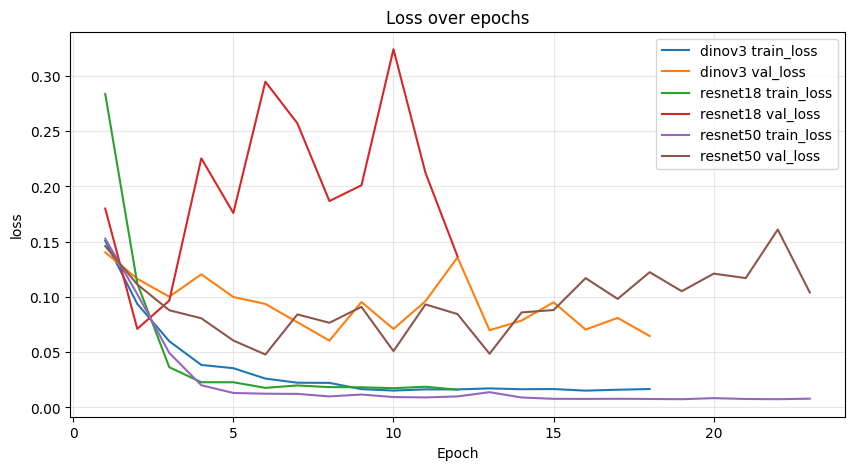

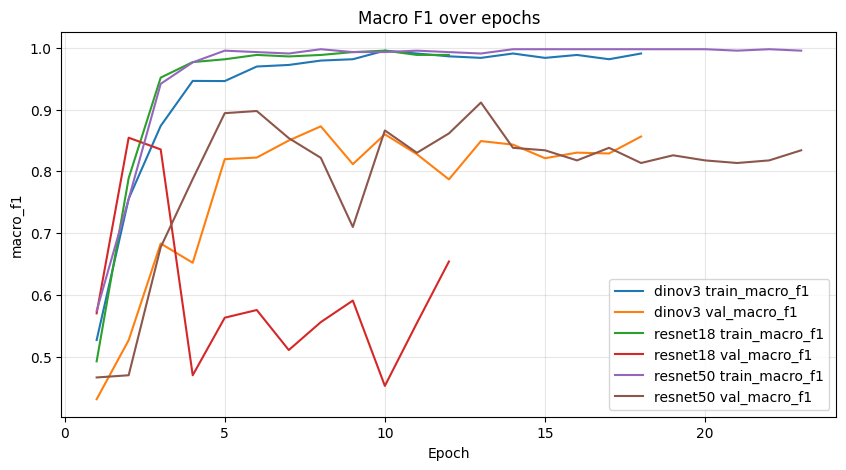

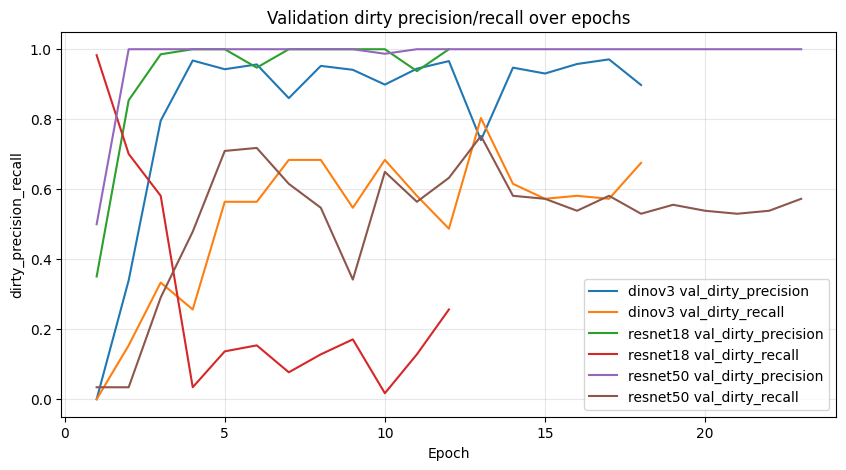

,model_name,test_macro_f1,test_dirty_precision,test_dirty_recall,test_acc,best_threshold
2,resnet50,0.711726,0.972973,0.363636,0.827027,0.311395
0,dinov3,0.668849,0.767442,0.333333,0.794595,0.410456
1,resnet18,0.577828,0.378641,0.393939,0.664865,0.415969


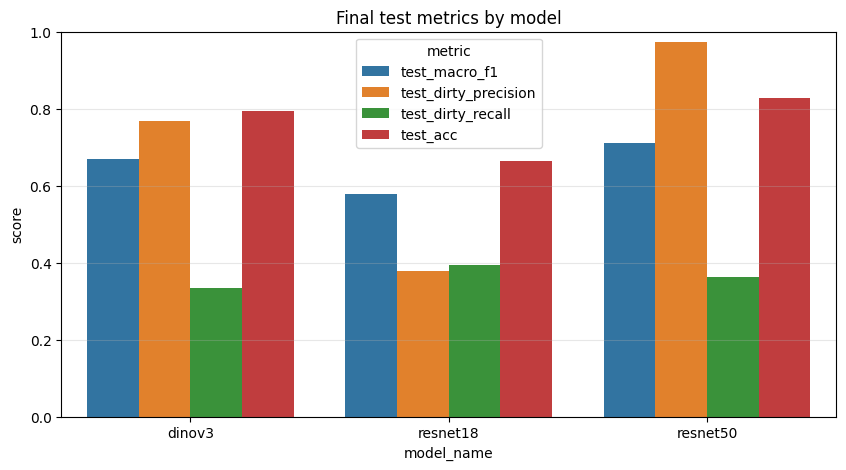

,model_name,best_val_macro_f1_mean,best_val_macro_f1_std,dirty_precision_mean,dirty_precision_std,dirty_recall_mean,dirty_recall_std,val_loss_mean
0,dinov3,0.823337,0.081296,0.826524,0.104111,0.544802,0.090428,0.086087
1,resnet18,0.841594,0.059846,0.872804,0.168089,0.496025,0.049744,0.109182
2,resnet50,0.817097,0.052216,0.801949,0.140802,0.546742,0.088342,0.091068


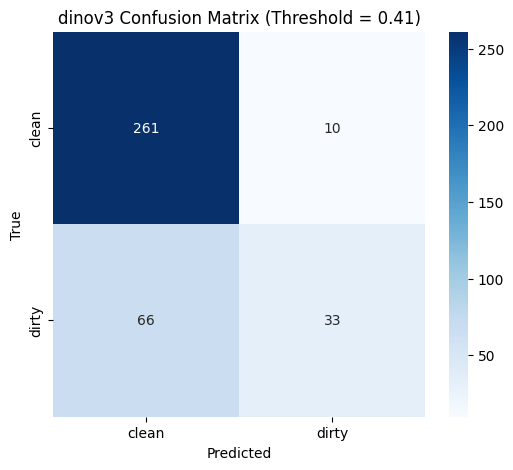

In [27]:
# Full train/val/test ablations with validation threshold tuning applied to test.
final_results = []
history_by_model = {}
trained_models = {}
thresholds_by_model = {}
reports_by_model = {}
confusions_by_model = {}

for model_name in ABLATION_MODELS:
    print(f"\n===== Final train/test run: {model_name} =====")
    set_seed(SEED)
    train_loader, val_loader, test_loader, balanced_train_idx = make_loaders(train_idx, val_idx, test_idx, seed=SEED)
    candidate_model = build_model(model_name)
    trained_model, best_val_f1, history = train_model(
        candidate_model,
        model_name,
        train_loader,
        val_loader,
        model_config(model_name, NUM_EPOCHS),
        device,
    )

    best_threshold, test_metrics, test_labels, test_preds = evaluate_with_threshold(trained_model, val_loader, test_loader, device)
    report = classification_report(test_labels, test_preds, target_names=list(id2label.values()))
    cm = confusion_matrix(test_labels, test_preds)

    print(f"\n{model_name} optimal decision threshold from val: {best_threshold:.4f}")
    print(f"{model_name} test accuracy: {100*test_metrics['acc']:.2f}%")
    print(report)

    final_results.append({
        'model_name': model_name,
        'best_val_macro_f1': best_val_f1,
        'best_threshold': best_threshold,
        'test_macro_f1': test_metrics['macro_f1'],
        'test_acc': test_metrics['acc'],
        'test_dirty_precision': test_metrics['dirty_precision'],
        'test_dirty_recall': test_metrics['dirty_recall'],
        'train_samples_after_undersampling': len(balanced_train_idx),
    })
    history_by_model[model_name] = history
    trained_models[model_name] = trained_model
    thresholds_by_model[model_name] = best_threshold
    reports_by_model[model_name] = report
    confusions_by_model[model_name] = cm

final_results_df = pd.DataFrame(final_results)
plot_history(history_by_model)
plot_model_comparison(final_results_df, cv_summary_df)

selected_model_name = FINAL_MODEL_NAME
model = trained_models[selected_model_name]
best_threshold = thresholds_by_model[selected_model_name]

plt.figure(figsize=(6, 5))
sns.heatmap(confusions_by_model[selected_model_name], annot=True, fmt='d', cmap='Blues', xticklabels=id2label.values(), yticklabels=id2label.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'{selected_model_name} Confusion Matrix (Threshold = {best_threshold:.2f})')
plt.show()


In [28]:
# Save the selected final model. By default this is the DINOv3 run.
save_dict = {
    'model_name': selected_model_name,
    'model_state_dict': model.state_dict(),
    'backbone_config': HF_MODELS[BACKBONE_SIZE] if selected_model_name == 'dinov3' else selected_model_name,
    'embed_dim': embed_dim if selected_model_name == 'dinov3' else None,
    'id2label': id2label,
    'label2id': label2id,
    'unfreeze_last_n': UNFREEZE_LAST_N if selected_model_name == 'dinov3' else None,
    'best_threshold': best_threshold,
    'clean_to_dirty_train_ratio': CLEAN_TO_DIRTY_TRAIN_RATIO,
    'dirty_frame_nums': DIRTY_FRAME_NUMS,
    'clean_frame_nums': CLEAN_FRAME_NUMS,
    'final_results': final_results_df.to_dict(orient='records'),
}

torch.save(save_dict, 'dirty_clean_classifier_full.pt')
print(f"Final {selected_model_name} model saved to dirty_clean_classifier_full.pt")

if selected_model_name == 'dinov3':
    torch.save(save_dict, 'dinov3_classifier_full.pt')
    print("Compatibility copy saved to dinov3_classifier_full.pt")


Final dinov3 model saved to dirty_clean_classifier_full.pt
Compatibility copy saved to dinov3_classifier_full.pt
